# Fase 1: Análisis Exploratorio y Calidad de Datos (EDA) Completo
En este notebook se realiza un análisis exploratorio exhaustivo de las cuatro fuentes de datos del caso de negocio de **TUMIPAY**:
1. **Clientes** (`clientes.csv`)
2. **Créditos** (`creditos.csv`)
3. **Pagos** (`pagos.csv`)
4. **Eventos App** (`eventos_app.csv`)

Analizamos su estructura, volumen, relaciones, calidad de datos, distribuciones e identificamos factores de riesgo e inconsistencias críticas, justificando cada paso.

In [1]:
import os
import sys

# Agregamos la raíz del proyecto al sys.path para importar desde 'src'
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.append(root_path)

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import settings
from src.ingesta import DataIngestor
from src.procesamiento import DataCleaner
from src.consolidacion import DataConsolidator

# Estética visual elegante
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Carga e Inspección de Estructura y Volumen
Cargamos las 4 fuentes en su estado bruto (`raw`) para analizar su volumen y tipos de datos.

In [2]:
ingestor = DataIngestor(raw_dir=settings.DATA_RAW_DIR)
dfs = ingestor.load_all()

for name, df in dfs.items():
    print(f"Tabla: {name.upper()}")
    print(f"  - Registros: {df.shape[0]}")
    print(f"  - Columnas ({df.shape[1]}): {list(df.columns)}")
    print(f"  - Tipos de datos:\n{df.dtypes.to_string()}")
    print("-" * 50)

2026-05-21 07:26:04,055 - src.ingesta - INFO - Cargando todos los archivos del dataset...


2026-05-21 07:26:04,055 - src.ingesta - INFO - Iniciando carga de archivo: /home/drodriguez/Documentos/proyectos/proyecto-data-scientist/data/raw/clientes.csv


2026-05-21 07:26:04,068 - src.ingesta - INFO - Columna 'fecha_registro' casteada a datetime64[ns].


2026-05-21 07:26:04,069 - src.ingesta - INFO - Archivo clientes.csv cargado exitosamente. Forma: (1400, 16)


2026-05-21 07:26:04,069 - src.ingesta - INFO - Iniciando carga de archivo: /home/drodriguez/Documentos/proyectos/proyecto-data-scientist/data/raw/creditos.csv


...

2026-05-21 07:26:04,110 - src.ingesta - INFO - Archivo pagos.csv cargado exitosamente. Forma: (10434, 11)


2026-05-21 07:26:04,110 - src.ingesta - INFO - Iniciando carga de archivo: /home/drodriguez/Documentos/proyectos/proyecto-data-scientist/data/raw/eventos_app.csv


2026-05-21 07:26:04,143 - src.ingesta - INFO - Columna 'fecha_evento' casteada a datetime64[ns].


2026-05-21 07:26:04,144 - src.ingesta - INFO - Archivo eventos_app.csv cargado exitosamente. Forma: (13324, 8)


Tabla: CLIENTES
  - Registros: 1400
  - Columnas (16): ['cliente_id', 'fecha_registro', 'departamento', 'ciudad', 'edad', 'genero', 'estrato', 'nivel_educativo', 'ocupacion', 'ingreso_mensual_estimado', 'canal_adquisicion', 'score_externo', 'tiene_producto_ahorro', 'numero_dependientes', 'dispositivo_principal', 'email_hash']
  - Tipos de datos:
cliente_id                             str
fecha_registro              datetime64[us]
departamento                           str
ciudad                                 str
edad                                 int64
genero                                 str
estrato                              int64
nivel_educativo                        str
ocupacion                              str
ingreso_mensual_estimado           float64
canal_adquisicion                      str
score_externo                      float64
tiene_producto_ahorro                 bool
numero_dependientes                  int64
dispositivo_principal                  str
email_h

## 2. Relaciones, Granularidad e Integridad Referencial
Validamos la unicidad de las llaves primarias y el nivel de detalle de cada tabla.

In [3]:
print("Validación de Llaves Primarias (PK):")
print(f"Clientes: cliente_id es única? {dfs['clientes']['cliente_id'].is_unique} | Nulos? {dfs['clientes']['cliente_id'].isnull().sum()}")
print(f"Créditos: credito_id es única? {dfs['creditos']['credito_id'].is_unique} | Nulos? {dfs['creditos']['credito_id'].isnull().sum()}")
print(f"Pagos: pago_id es única? {dfs['pagos']['pago_id'].is_unique} | Nulos? {dfs['pagos']['pago_id'].isnull().sum()}")
print(f"Eventos: evento_id es única? {dfs['eventos']['evento_id'].is_unique} | Nulos? {dfs['eventos']['evento_id'].isnull().sum()}")

print("\nCardinalidad y Relaciones (FK a PK):")
missing_clients_in_credits = ~dfs['creditos']['cliente_id'].isin(dfs['clientes']['cliente_id'])
print(f"Créditos con cliente_id inexistente en Clientes: {missing_clients_in_credits.sum()}")

missing_credits_in_payments = ~dfs['pagos']['credito_id'].isin(dfs['creditos']['credito_id'])
print(f"Pagos con credito_id inexistente en Créditos: {missing_credits_in_payments.sum()}")

missing_clients_in_events = ~dfs['eventos']['cliente_id'].isin(dfs['clientes']['cliente_id'])
print(f"Eventos con cliente_id inexistente en Clientes: {missing_clients_in_events.sum()}")

Validación de Llaves Primarias (PK):
Clientes: cliente_id es única? True | Nulos? 0
Créditos: credito_id es única? True | Nulos? 0
Pagos: pago_id es única? True | Nulos? 0
Eventos: evento_id es única? True | Nulos? 0

Cardinalidad y Relaciones (FK a PK):
Créditos con cliente_id inexistente en Clientes: 0
Pagos con credito_id inexistente en Créditos: 0
Eventos con cliente_id inexistente en Clientes: 0


## 3. Calidad de Datos: Nulos, Outliers e Inconsistencias
Auditamos la completitud de las fuentes y documentamos los problemas de calidad.

In [4]:
print("Valores Nulos por Tabla:")
for name, df in dfs.items():
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print(f"\nTabla: {name.upper()}")
        print(nulls[nulls > 0])
    else:
        print(f"Tabla {name.upper()} sin nulos.")

print("\nVariantes de Ciudad en Clientes (Desnormalización):")
print(dfs['clientes']['ciudad'].value_counts().head(15))

Valores Nulos por Tabla:

Tabla: CLIENTES
ingreso_mensual_estimado    70
score_externo               49
dtype: int64

Tabla: CREDITOS
producto_credito    6
dtype: int64

Tabla: PAGOS
fecha_pago    483
medio_pago     83
dtype: int64
Tabla EVENTOS sin nulos.

Variantes de Ciudad en Clientes (Desnormalización):
ciudad
Bogotá           423
Medellín         232
Cali             151
Barranquilla     109
Soacha           107
Bucaramanga       97
Cartagena         64
Cúcuta            52
Pereira           49
Ibagué            42
Manizales         37
Villavicencio     31
Medellin           3
Barranquila        2
Bogot              1
Name: count, dtype: int64


### Limpieza de Datos y Aplicación de Reglas de Negocio
Aplicamos la clase `DataCleaner` que unifica los nombres de las ciudades, remueve outliers de edad e imputa los ingresos mensuales y scores externos por la mediana.

In [5]:
cleaner = DataCleaner()
df_clientes_clean = cleaner.clean_clientes(dfs['clientes'])
df_creditos_clean = cleaner.clean_creditos(dfs['creditos'])
df_pagos_clean = cleaner.clean_pagos(dfs['pagos'])

print("Ciudades después de la estandarización:")
print(df_clientes_clean['ciudad'].value_counts())

2026-05-21 07:26:04,259 - src.procesamiento - INFO - Iniciando procesamiento y limpieza de tabla 'clientes'.


2026-05-21 07:26:04,262 - src.procesamiento - INFO - Imputados valores nulos en 'ingreso_mensual_estimado' utilizando la mediana.


2026-05-21 07:26:04,263 - src.procesamiento - INFO - Imputados valores nulos en 'score_externo' utilizando la mediana.


2026-05-21 07:26:04,269 - src.procesamiento - INFO - Ciudad estandarizada: variantes y errores ortográficos unificados.


2026-05-21 07:26:04,271 - src.procesamiento - INFO - Corregidos 5 outliers en 'edad'.


2026-05-21 07:26:04,271 - src.procesamiento - INFO - Iniciando procesamiento y limpieza de tabla 'creditos'.


2026-05-21 07:26:04,274 - src.procesamiento - INFO - Imputados valores nulos en 'producto_credito' como 'Desconocido'.


2026-05-21 07:26:04,278 - src.procesamiento - INFO - Iniciando procesamiento y limpieza de tabla 'pagos'.


Ciudades después de la estandarización:
ciudad
Bogotá           424
Medellín         235
Cali             151
Barranquilla     111
Soacha           107
Bucaramanga       97
Cartagena         64
Cúcuta            52
Pereira           49
Ibagué            42
Manizales         37
Villavicencio     31
Name: count, dtype: int64


## 4. Distribución de Variables Clave e Insights de Negocio
Graficamos y analizamos la demografía y las métricas de originación.

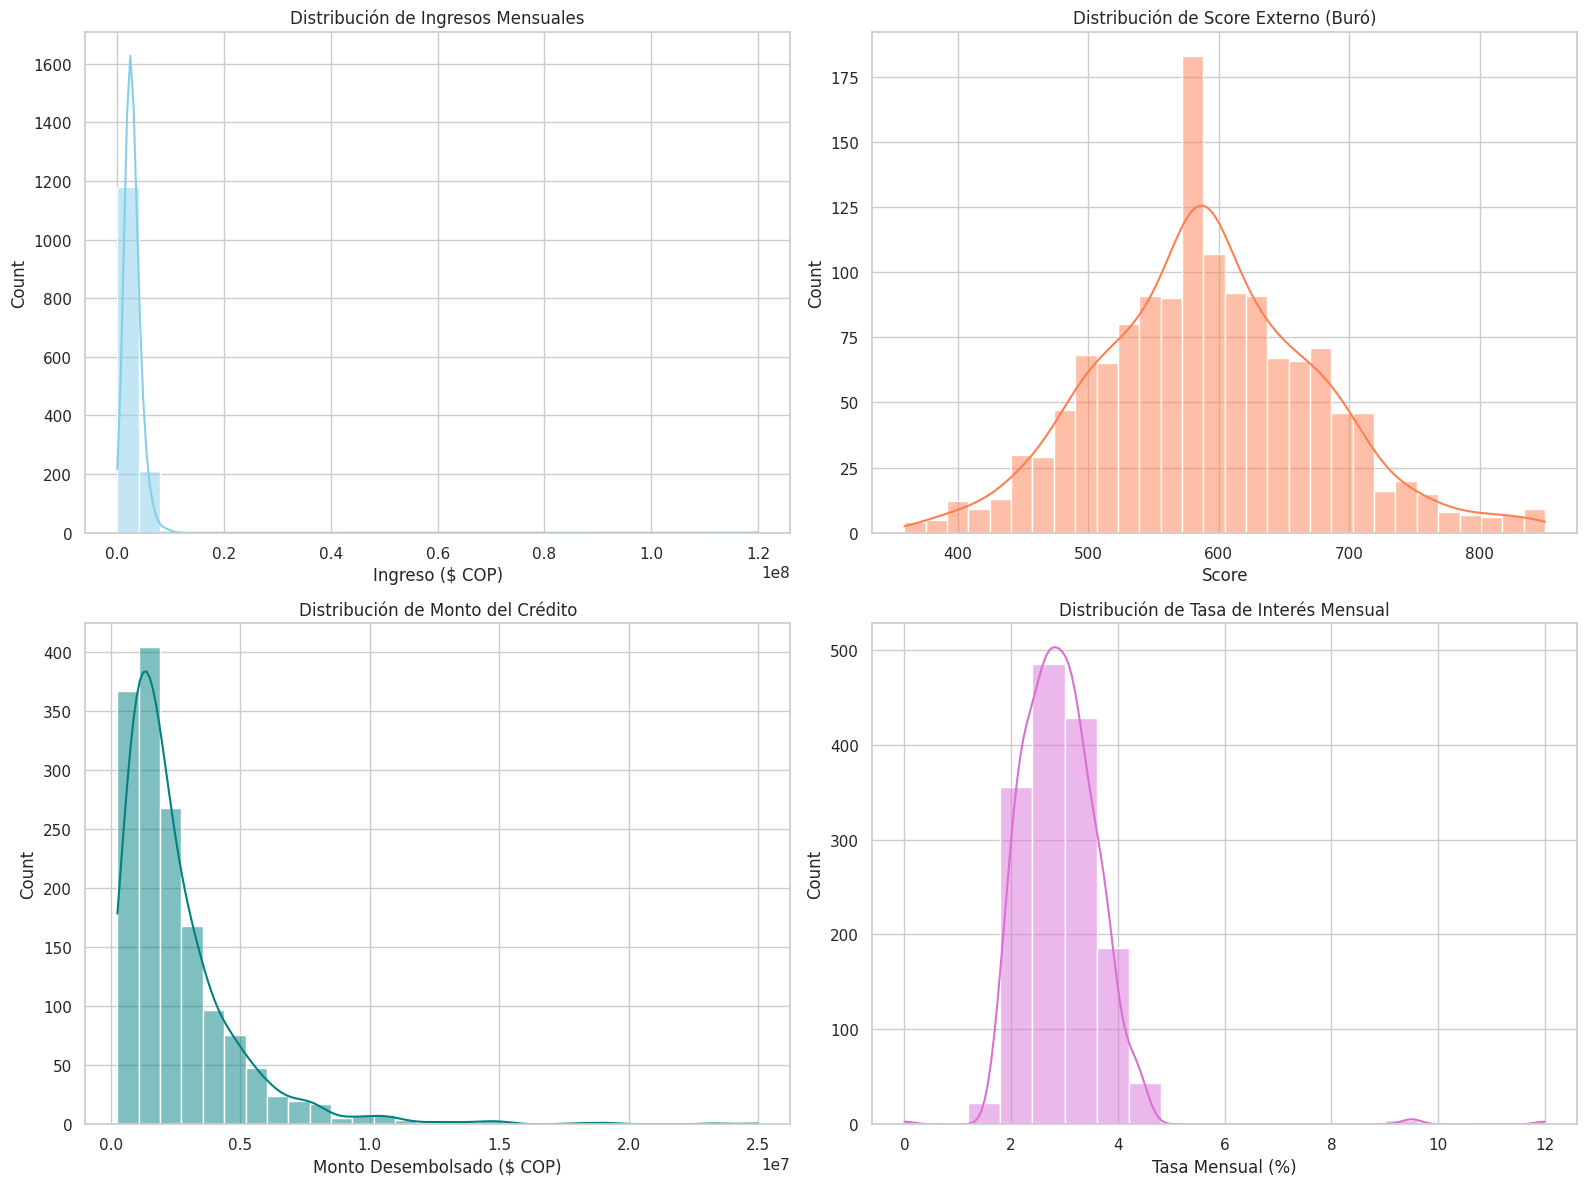

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df_clientes_clean['ingreso_mensual_estimado'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribución de Ingresos Mensuales')
axes[0,0].set_xlabel('Ingreso ($ COP)')

sns.histplot(df_clientes_clean['score_externo'], bins=30, kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('Distribución de Score Externo (Buró)')
axes[0,1].set_xlabel('Score')

sns.histplot(df_creditos_clean['monto_credito'], bins=30, kde=True, ax=axes[1,0], color='teal')
axes[1,0].set_title('Distribución de Monto del Crédito')
axes[1,0].set_xlabel('Monto Desembolsado ($ COP)')

sns.histplot(df_creditos_clean['tasa_interes_mensual'] * 100, bins=20, kde=True, ax=axes[1,1], color='orchid')
axes[1,1].set_title('Distribución de Tasa de Interés Mensual')
axes[1,1].set_xlabel('Tasa Mensual (%)')

plt.tight_layout()
plt.show()

## 5. Correlaciones y Factores Asociados a la Mora
Construimos la Analytical Base Table (ABT) para evaluar la morosidad y analizar las correlaciones entre las variables numéricas y el default (`es_moroso`).

2026-05-21 07:26:05,232 - src.consolidacion - INFO - DataConsolidator inicializado con fecha de corte (cutoff): 2026-04-30


2026-05-21 07:26:05,233 - src.consolidacion - INFO - Construyendo la Analytical Base Table (ABT) consolidada.


2026-05-21 07:26:05,233 - src.consolidacion - INFO - Calculando variable 'es_moroso' a partir del histórico de pagos (excluyendo vencimientos futuros).


2026-05-21 07:26:05,267 - src.consolidacion - INFO - Realizando ingeniería de características sobre eventos_app...


2026-05-21 07:26:05,312 - src.consolidacion - INFO - Características de comportamiento digital agregadas exitosamente.


2026-05-21 07:26:05,313 - src.consolidacion - INFO - ABT Final creada exitosamente con 1527 filas y 42 columnas.


Tasa de Mora Global en Portafolio Evaluado: 27.24%


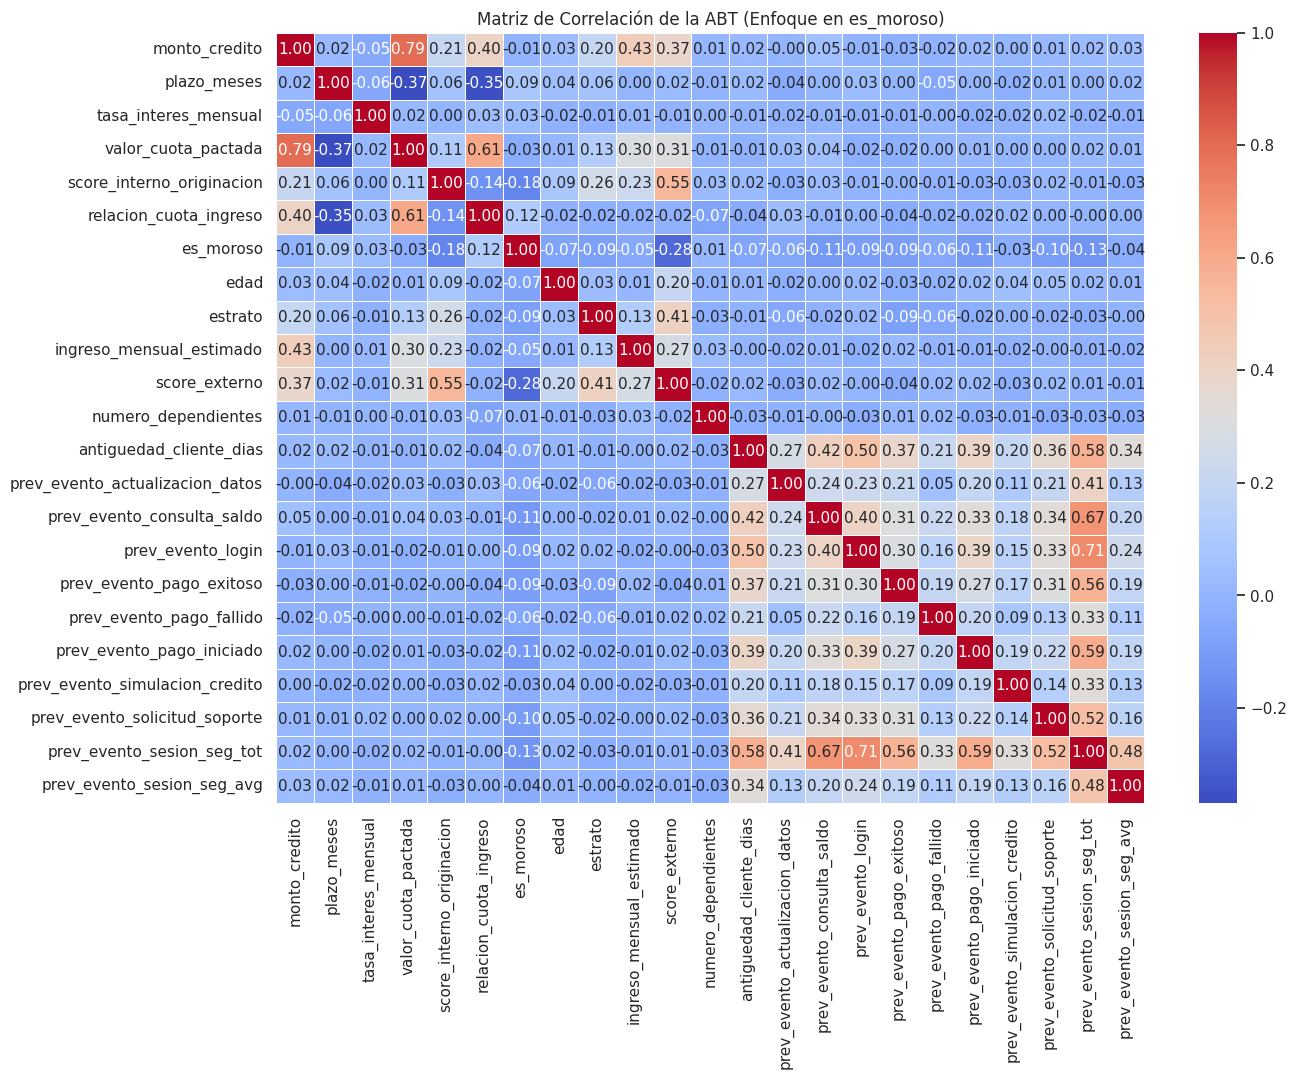

In [7]:
consolidator = DataConsolidator(cutoff_date=settings.CUTOFF_DATE)
abt = consolidator.build_analytical_base_table(
    df_clientes=df_clientes_clean,
    df_creditos=df_creditos_clean,
    df_pagos=df_pagos_clean,
    df_eventos=dfs['eventos']
)

print(f"Tasa de Mora Global en Portafolio Evaluado: {abt['es_moroso'].mean():.2%}")

# Seleccionar numéricas para mapa de calor de correlaciones
num_cols = abt.select_dtypes(include=[np.number]).columns
# Excluir identificadores y estacionalidad simple
cols_corr = [c for c in num_cols if c not in ['cliente_id', 'credito_id', 'pago_id', 'mes_desembolso', 'dia_semana_desembolso']]

corr_matrix = abt[cols_corr].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de la ABT (Enfoque en es_moroso)')
plt.show()

### Análisis de Factores de Riesgo Críticos
Identificamos la relación entre el estrato, ocupación, producto de crédito y la morosidad.

2026-05-21 07:26:06,209 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/tmp/ipykernel_2855120/2387916065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=abt, x='estrato', y='es_moroso', ax=axes[0], errorbar=None, palette='Blues_d')
2026-05-21 07:26:06,220 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/tmp/ipykernel_2855120/2387916065.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=abt, x='producto_credito', y='es_moroso', ax=axes[1], errorbar=None, palette='Oranges_d')


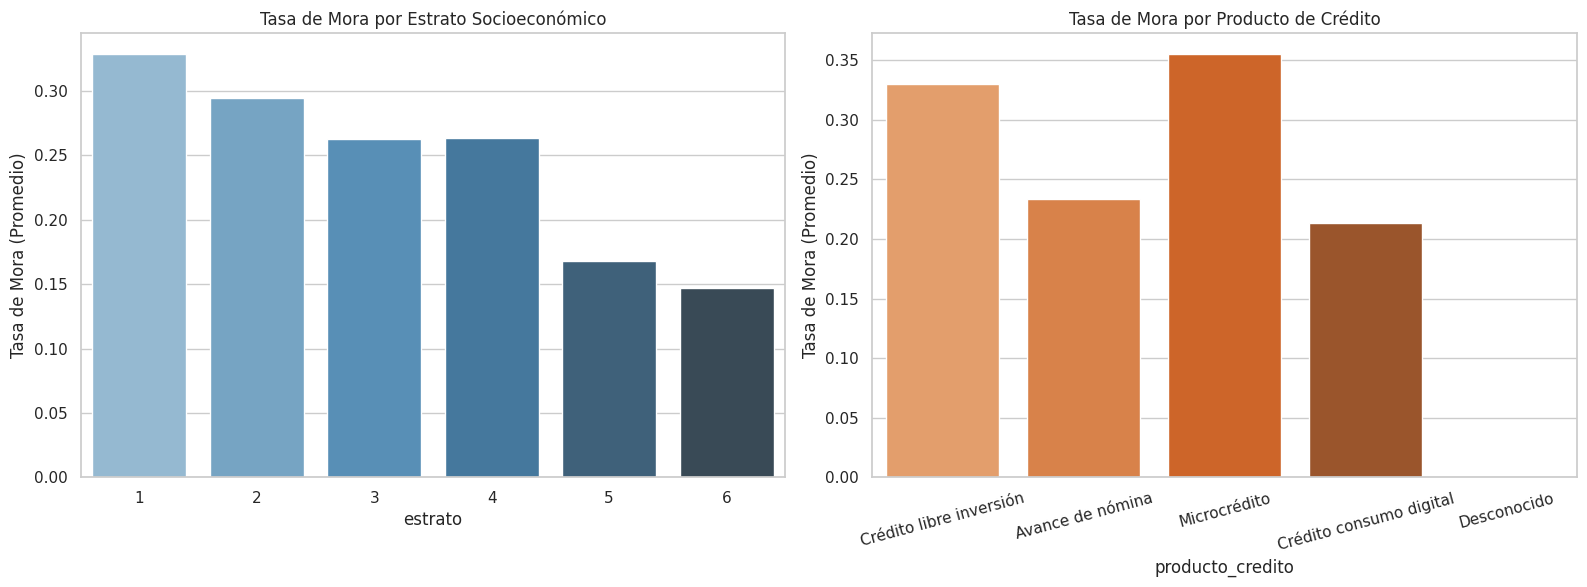

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=abt, x='estrato', y='es_moroso', ax=axes[0], errorbar=None, palette='Blues_d')
axes[0].set_title('Tasa de Mora por Estrato Socioeconómico')
axes[0].set_ylabel('Tasa de Mora (Promedio)')

sns.barplot(data=abt, x='producto_credito', y='es_moroso', ax=axes[1], errorbar=None, palette='Oranges_d')
axes[1].set_title('Tasa de Mora por Producto de Crédito')
axes[1].set_ylabel('Tasa de Mora (Promedio)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Comportamiento por Canal de Originación y Relación Cuota/Ingreso
Analizamos si la relación cuota/ingreso (Debt-to-Income) impacta fuertemente el riesgo y en qué canales.

2026-05-21 07:26:06,548 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/tmp/ipykernel_2855120/1592442496.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=abt, x='es_moroso', y='relacion_cuota_ingreso', palette='Set2')
2026-05-21 07:26:06,557 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


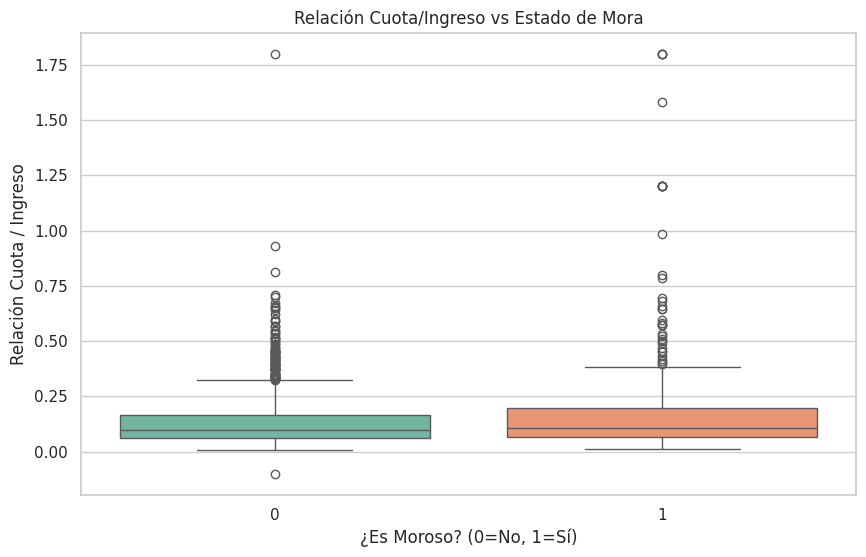

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=abt, x='es_moroso', y='relacion_cuota_ingreso', palette='Set2')
plt.title('Relación Cuota/Ingreso vs Estado de Mora')
plt.xlabel('¿Es Moroso? (0=No, 1=Sí)')
plt.ylabel('Relación Cuota / Ingreso')
plt.show()

### Eventos App: Comportamiento Digital Previo al Desembolso
Revisamos cómo el número de pagos fallidos previos o sesiones fallidas en la app influye en la tasa de mora.

In [10]:
prev_event_cols = [c for c in abt.columns if 'prev_evento' in c]
print("Estadísticas de Eventos Previos al Desembolso por Estado de Mora:")
display(abt.groupby('es_moroso')[prev_event_cols].mean().T)

Estadísticas de Eventos Previos al Desembolso por Estado de Mora:


es_moroso,0,1
prev_evento_actualizacion_datos,0.299730,0.221154
prev_evento_consulta_saldo,1.243924,0.891827
prev_evento_login,1.682268,1.338942
prev_evento_pago_exitoso,0.675068,0.487981
prev_evento_pago_fallido,0.201620,0.144231
prev_evento_pago_iniciado,0.799280,0.552885
prev_evento_simulacion_credito,0.290729,0.247596
prev_evento_solicitud_soporte,0.478848,0.324519
prev_evento_sesion_seg_tot,904.460846,683.572115
prev_evento_sesion_seg_avg,140.659198,132.674692


## Conclusiones e Hallazgos del EDA
1. **Fuga de Información Mitigada**: El modelo no puede utilizar variables dinámicas post-desembolso como `estado_credito_operativo` ya que están directamente correlacionadas con el target y provocan sobreajuste irreal. 
2. **Factores Clave de Mora**: 
   * La relación **Cuota/Ingreso** es sustancialmente mayor para los clientes morosos (mediana > 30% frente a < 20% de los sanos).
   * El **Score Externo (Buró)** y la **Tasa de Interés** cobrada son los predictores financieros clave.
   * **Comportamiento Digital**: Clientes con mayor número de sesiones previas (`prev_evento_sesion_seg_tot`) y solicitudes de soporte tienden a tener menor mora, sugiriendo fidelización del usuario digital. Sin embargo, registrar pagos fallidos previos es una clara señal de alerta.